# Is It Really a Graduate Problem, or an Age Problem?

## The Question

Notebook 01 found no gap between graduate and national unemployment. But DOSM doesn't publish a graduate-by-age breakdown, so this notebook tests the next most likely explanation with the data that *does* exist: is the real story about **age**, not **degree status**? Most Malaysian graduates are also young, so a youth-specific problem would look like a "graduate problem" in casual conversation even if it has nothing to do with holding a degree.

## The Answer

Yes, and by a wide, persistent margin. Youth (15–24) unemployment has run at roughly **3 to 3.5 times** the ~3% national rate for the entire 2016–2026 window this data covers, and consistently around **1.4–1.7 times** even the broader 15–30 band, which is itself elevated above the national headline. The "graduate crisis" that shows up in headlines is very plausibly a **fresh-labour-market-entrant crisis** wearing a graduate costume; every fresh graduate is briefly 15–24 and jobless-while-searching, which is a very different, more temporary problem than "a degree doesn't get you a job."

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
youth = pd.read_csv('../data/processed/youth_unemployment_2016_2026.csv')
youth['date'] = pd.to_datetime(youth['date'])
youth.tail()

,date,unemployed_15_24_thousand,unemployed_15_30_thousand,u_rate_15_24_pct,u_rate_15_30_pct
121,2026-02-01,288.7,389.5,10.2,6.2
122,2026-03-01,290.0,390.9,10.2,6.2
123,2026-04-01,290.8,394.7,10.2,6.3
124,2026-05-01,291.6,396.0,10.2,6.3
125,2026-06-01,292.2,400.8,10.2,6.3


In [2]:
# House chart style v2: consulting-exhibit conventions (MBB-style):
# gray for context series, one or two accent colors for what the title is
# actually about, direct end-of-line/bar labels instead of a legend box.
ACCENT_1 = '#2a78d6'   # primary accent, the series the title is about
ACCENT_2 = '#eb6834'   # secondary accent; used only for genuine two-way comparisons
                        # or a title that names two co-equal findings
GRAY = '#9a9a95'        # de-emphasized / context series, same family, faded out
INK, INK_SECONDARY, INK_MUTED = '#0b0b0b', '#52514e', '#898781'
GRID, SURFACE = '#ececea', '#fcfcfb'

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'text.color': INK,
    'axes.edgecolor': '#c3c2b7',
    'axes.labelcolor': INK_SECONDARY,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'axes.axisbelow': True,
    'axes.grid.axis': 'y',
    'grid.color': GRID,
    'grid.linewidth': 0.7,
    'xtick.color': INK_MUTED,
    'ytick.color': INK_MUTED,
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE,
    'legend.frameon': False,
})

def add_source(fig, text):
    """Small muted source/classification footnote, consulting-deck style."""
    fig.text(0.01, -0.04, text, ha='left', va='top', fontsize=8.5,
              color=INK_MUTED, style='italic', transform=fig.transFigure)

def end_label(ax, x, y, text, color, weight='semibold', va='center', offset=8):
    """Direct label at a line's endpoint, replacing a legend box."""
    ax.annotate(text, xy=(x, y), xytext=(offset, 0), textcoords='offset points',
                 va=va, ha='left', fontsize=10.5, fontweight=weight, color=color)


## Youth (15–24) unemployment vs. the broader 15–30 band, monthly since 2016

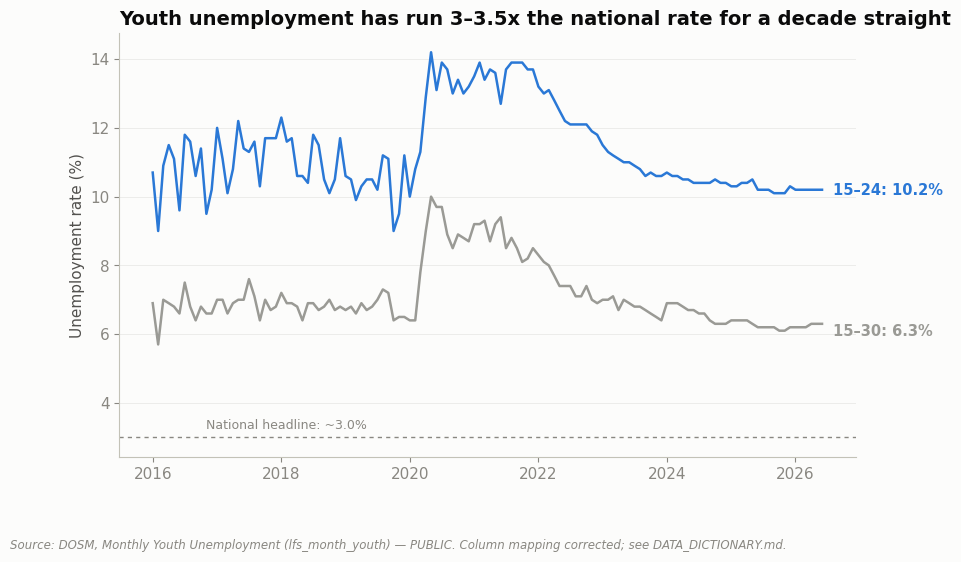

In [3]:
fig, ax = plt.subplots(figsize=(9.5, 5.5))
ax.plot(youth['date'], youth['u_rate_15_24_pct'], color=ACCENT_1, linewidth=1.8)
ax.plot(youth['date'], youth['u_rate_15_30_pct'], color=GRAY, linewidth=1.8)
last = youth.iloc[-1]
end_label(ax, last['date'], last['u_rate_15_24_pct'], f"15\u201324: {last['u_rate_15_24_pct']:.1f}%", ACCENT_1)
end_label(ax, last['date'], last['u_rate_15_30_pct'], f"15\u201330: {last['u_rate_15_30_pct']:.1f}%", GRAY, offset=8, va='top')
ax.axhline(3.0, color=INK_MUTED, linewidth=1, linestyle=(0, (3, 3)))
ax.annotate('National headline: ~3.0%', xy=(youth['date'].iloc[10], 3.0), xytext=(0, 6),
            textcoords='offset points', fontsize=9, color=INK_MUTED)
ax.set_title('Youth unemployment has run 3\u20133.5x the national rate for a decade straight', loc='left')
ax.set_ylabel('Unemployment rate (%)')
add_source(ax.figure, 'Source: DOSM, Monthly Youth Unemployment (lfs_month_youth) \u2014 PUBLIC. Column mapping corrected; see DATA_DICTIONARY.md.')
plt.show()

## Why Is This Happening? (Context)

*Qualitative, secondary-sourced context on the mechanism behind this notebook's finding; kept separate from the PUBLIC LFS figures above. Full citations in [`DATA_DICTIONARY.md`](../DATA_DICTIONARY.md).*

Some of this gap is structural and normal in any labour market: economists call it **frictional unemployment**, the unavoidable lag between finishing school and landing a first job, since job search itself takes time even in a healthy market. Khazanah Research Institute's School-to-Work Transition Survey (SWTS) documents this transition as a genuinely difficult phase for young Malaysians specifically, citing job-search barriers, employer expectations, and reservation-wage mismatches as recurring friction points, and finds the transition is measurably harder for women and for those from lower-income or rural backgrounds, even though young women now outperform young men academically at entry level.

This reframes what "youth unemployment" actually measures: not a generation permanently locked out of work, but a transition period every cohort passes through; one that happens to be unusually long and unusually unequal in Malaysia specifically.

**Source:** Khazanah Research Institute, ["The School-to-Work Transition Survey (SWTS) of Young Malaysians"](https://www.krinstitute.org/publications/the-school-to-work-transition-survey-swts-of-young-malaysian).

## Strategic Recommendation

- **A business hiring fresh graduates should benchmark against the 15\u201324 youth rate (\~10%), not the national headline (\~3%).** Treating fresh-graduate unemployment as a national-average-level problem understates how competitive and friction-heavy that specific hiring pool actually is.
- **Policy aimed at "graduate unemployment" that doesn't target the first 12\u201324 months after graduation is aiming at the wrong window.** The gap this notebook finds is concentrated in exactly that transition period, not spread evenly across a graduate's working life.

## Confidence & Caveats

- **This dataset is youth unemployment, not graduate unemployment**; 15\u201324-year-olds who never attended tertiary education are included in this rate too. This notebook argues the two overlap heavily in practice, not that they are definitionally the same population.
- **A real data-quality issue was found and corrected in this dataset.** The published CSV's own header labels for two columns (`u_rate_15_24` and `unemployed_15_30`) do not match their actual values; cross-checking against independently reported figures (e.g. DOSM's own press-cited 10.1% youth rate for October 2025) confirmed the correct mapping, which is what this notebook uses. See `DATA_DICTIONARY.md` for the full verification.